## Comparing the fitted Transfer Function parameters across neuron types

Ilaria Carannante

mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se

NeuroPSI, ICN, Saclay, France

---
### What this notebook is for

Run `Analysing_params_distribution_{FS,RS,RS_no_adapt}.ipynb` first. This notebook
asks whether the identifiability structure they each report is a property of the
**formalism** or of a **particular population**. If the same structure appears in all
three, it is the formalism -- which is the more general and more useful claim for a
pipeline paper.

**Two things make cross-model comparison harder than it looks, and both are handled
explicitly below.**

1. *The sign of a principal component is arbitrary.* Comparing PC1 loadings across
   models without aligning signs first is a coin flip: an inverted component reads as
   opposite structure when it is identical. Handled by `align_pca_signs`.
2. *Scores from separate PCAs live in different bases.* `X_pca_FS` and `X_pca_RS` are
   coordinates in different spaces; overlaying them on shared axes is not meaningful.
   To compare positions, all ensembles must be projected onto one basis. Handled by
   `pooled_pca`.

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..',))
sys.path.append(parent_dir)

from utils.Plots_helper import *
from ntmf.analysis_helper import *

from sklearn.decomposition import PCA
from scipy.stats import pearsonr

In [2]:
# ============================================================== #
#  CONFIGURATION
# ============================================================== #
neuron_models = ['FS', 'RS', 'RS_no_adapt']

results_tpl = '../fitting/results/10_best_params_TF_{}.json'

STANDARDIZE = True     # keep consistent with the per-model notebooks
N_CLUSTERS  = 'auto'
REFERENCE   = 'FS'     # model whose component signs the others are aligned to

fig_name = 'Comparing_TF_fitted_params_' + '_'.join(neuron_models)

params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2',
               'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

In [3]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig)

---
## 1. Load

Everything is kept in dictionaries keyed by neuron model, so that no variable is
silently overwritten by the next population and adding a fourth population needs no
new code.

In [4]:
poly = {}     # raw coefficients
poly_zs = {}  # z-scored, per model
alpha = {}
err = {}

for m in neuron_models:
    with open(results_tpl.format(m), 'r') as f:
        data = json.load(f)
    poly[m]  = np.array([d['polynomial_params'] for d in data])
    alpha[m] = np.array([d['alpha'] for d in data])
    err[m]   = np.array([d['mean_error'] for d in data])
    poly_zs[m] = (poly[m] - poly[m].mean(axis=0)) / poly[m].std(axis=0, ddof=1)
    print(f'{m:>12s}: {poly[m].shape[0]} fits, '
          f'alpha {alpha[m].min():.3f}-{alpha[m].max():.3f}, '
          f'error {err[m].min():.3f}-{err[m].max():.3f}')

n_params = poly[neuron_models[0]].shape[1]

          FS: 10 fits, alpha 1.113-1.191, error 6.398-7.644
          RS: 10 fits, alpha 1.080-1.887, error 0.156-0.171
 RS_no_adapt: 10 fits, alpha 1.040-1.063, error 3.379-3.522


---
## 2. Per-model reports

The same report the individual notebooks print, side by side.

In [5]:
labels = {}
cluster_diag = {}
pcas = {}
scores = {}
expl = {}

for m in neuron_models:
    labels[m], cluster_diag[m] = detect_clusters(poly[m], n_clusters=N_CLUSTERS)
    X = poly_zs[m] if STANDARDIZE else poly[m]
    pcas[m] = PCA().fit(X)
    scores[m] = pcas[m].transform(X)
    expl[m] = pcas[m].explained_variance_ratio_

In [6]:
for m in neuron_models:
    diagnostic_report(m, poly[m], alpha[m], err[m], params_name,
                      labels=labels[m], expl_var=expl[m])
    print()

  IDENTIFIABILITY REPORT  --  FS   (10 retained fits)

  Error range          : 6.398 - 7.644 (19.5% spread)
  Alpha range          : 1.113 - 1.191

  Stiffest coefficient : P_0 (CV = 1.6%)
  Sloppiest            : P_sig2 (CV = 308%)
  Collinearity         : median |r| = 0.93, 84% of pairs above 0.8
  Effective dimension  : 2 PC(s) reach 95% of the variance (PC1 alone = 91.1%)

  Clusters detected    : 2
  Cluster sizes         : 6, 4
  >> EFFECTIVE SAMPLE SIZE IS 2, NOT 10.
     Correlations and p-values over the rows are not valid.

  Reading: high collinearity + one dominant PC means the fitted
  coefficients are not individually identifiable. Report the fitted
  SURFACE and its domain of validity, not the coefficient values.

  IDENTIFIABILITY REPORT  --  RS   (10 retained fits)

  Error range          : 0.156 - 0.171 (9.6% spread)
  Alpha range          : 1.080 - 1.887

  Stiffest coefficient : P_0 (CV = 0.5%)
  Sloppiest            : P_tau2 (CV = 35%)
  Collinearity         : med

---
## 3. Cross-model summary

The table a reader of the paper needs. Each row is one population; each column is one
of the questions the individual notebooks answer.

In [7]:
rows = []
for m in neuron_models:
    s = coefficient_stats(poly[m], params_name)
    C = np.corrcoef(poly_zs[m].T)
    coll = collinearity_summary(C)
    n95 = int(np.searchsorted(np.cumsum(expl[m]), 0.95) + 1)
    rows.append({
        'model'        : m,
        'n_fits'       : poly[m].shape[0],
        'n_clusters'   : len(np.unique(labels[m])),
        'stiffest'     : s.iloc[0].params_name,
        'stiffest_CV%' : 100 * s.iloc[0].cv,
        'sloppiest'    : s.iloc[-1].params_name,
        'sloppiest_CV%': 100 * s.iloc[-1].cv,
        'median|r|'    : coll['median_abs_r'],
        'PC1%'         : 100 * expl[m][0],
        'nPC_95%'      : n95,
        'err_spread%'  : 100 * np.ptp(err[m]) / err[m].min(),
    })

summary_table = pd.DataFrame(rows)
print(summary_table.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

      model  n_fits  n_clusters stiffest  stiffest_CV% sloppiest  sloppiest_CV%  median|r|  PC1%  nPC_95%  err_spread%
         FS      10           2      P_0          1.60    P_sig2         307.74       0.93 91.05        2        19.47
         RS      10           1      P_0          0.49    P_tau2          34.85       0.50 55.94        4         9.58
RS_no_adapt      10           1      P_0          0.67 P_sig_tau         706.42       0.91 88.83        2         4.22


**What agreement across rows means.** If all three populations show the same cluster
count, the same stiffest coefficient, and comparable collinearity, then the
identifiability structure follows from the transfer-function formalism and the fitting
objective -- not from the biophysics of any one population. That is a statement about
the method, and it is what a pipeline paper should report.

If they disagree, the interesting question is which population differs and whether it
is the adaptive one: comparing RS against RS_no_adapt isolates adaptation, since the
two differ in nothing else.

---
## 4. Stiff and sloppy coefficients

Stiff-to-sloppy ranking per model:
            FS: P_0 < P_mu2 < P_mu_tau < P_tau < P_tau2 < P_sig_tau < P_sig < P_mu < P_mu_sig < P_sig2
            RS: P_0 < P_mu < P_sig < P_mu2 < P_sig2 < P_mu_tau < P_mu_sig < P_tau < P_sig_tau < P_tau2
   RS_no_adapt: P_0 < P_mu2 < P_mu < P_mu_tau < P_mu_sig < P_tau < P_sig2 < P_tau2 < P_sig < P_sig_tau


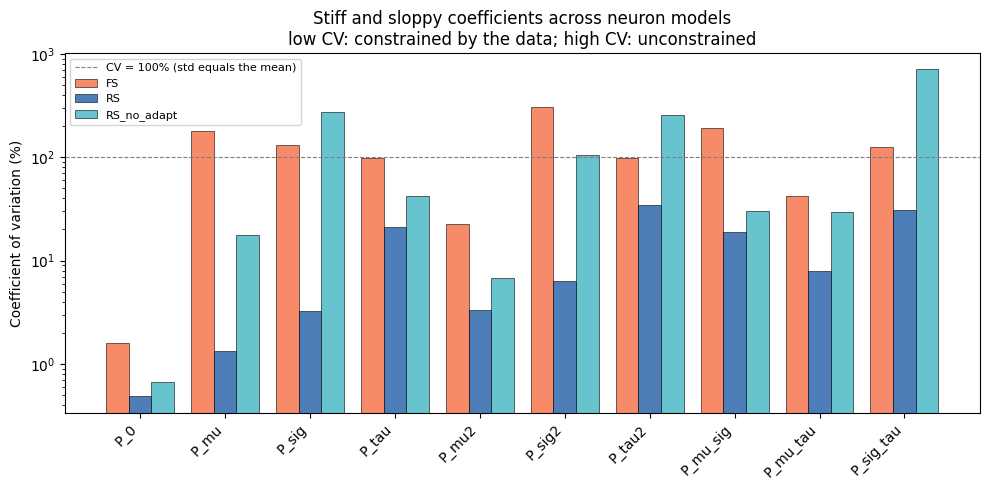

In [8]:
stats_dict = {m: coefficient_stats(poly[m], params_name) for m in neuron_models}

fig = plot_cv_comparison(stats_dict, params_name)
figs.append(fig)

print('Stiff-to-sloppy ranking per model:')
for m in neuron_models:
    print(f"  {m:>12s}: {' < '.join(stats_dict[m].params_name)}")


A coefficient that is stiff in every population is the one quantity this fitting
procedure genuinely determines. A coefficient that is sloppy everywhere should not be
reported as a fitted value in any of them.

---
## 5. Clusteres per model

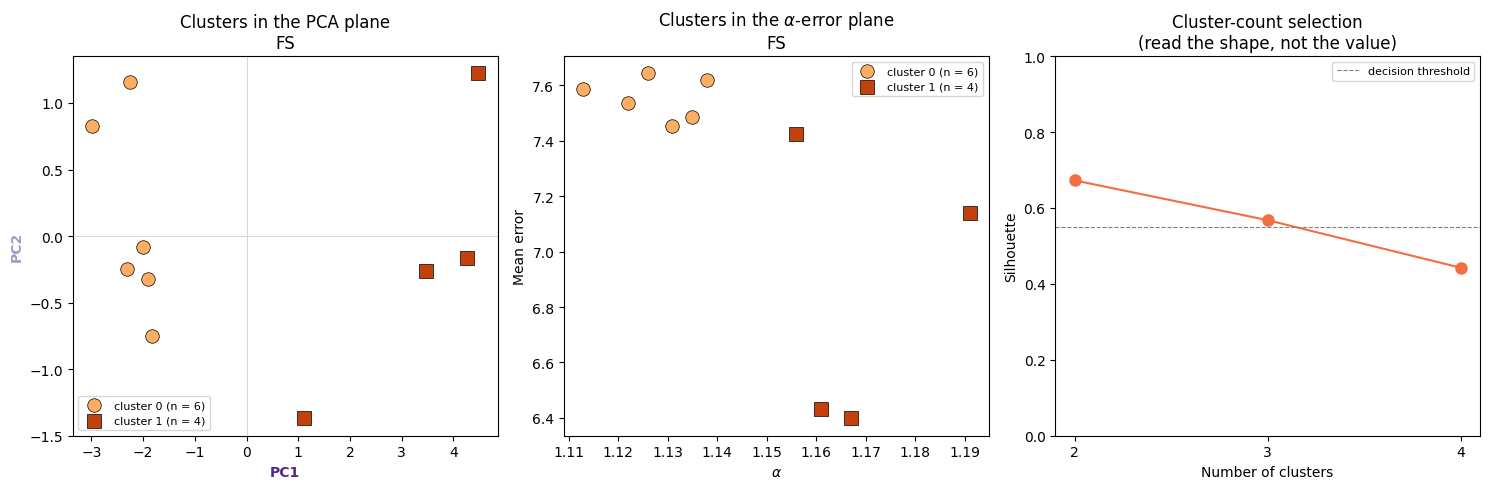

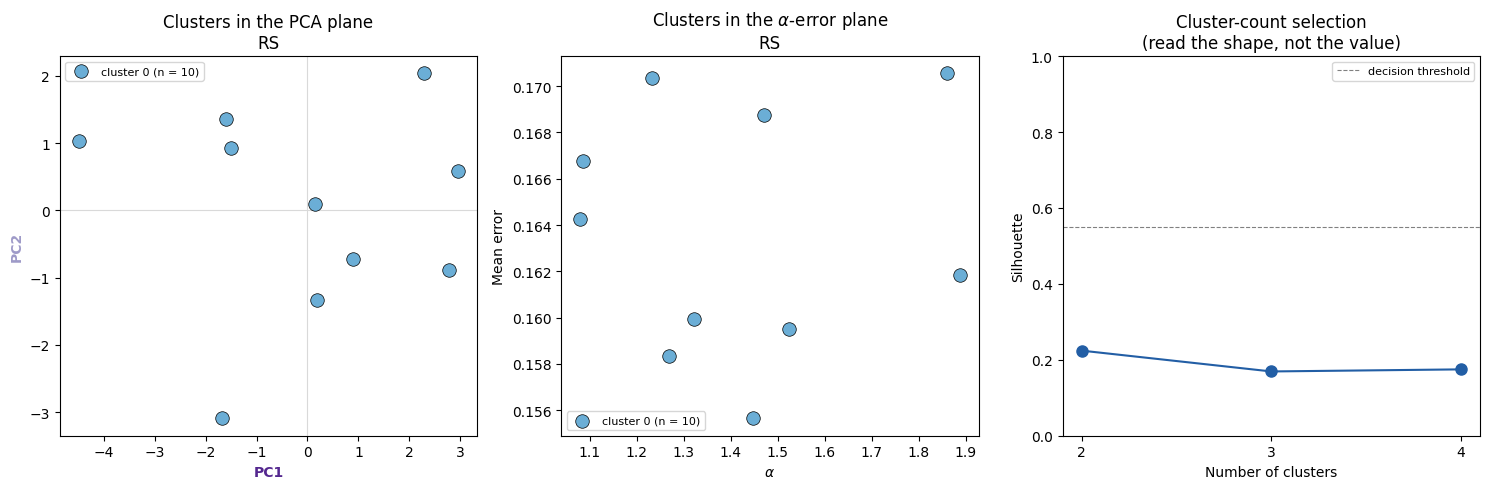

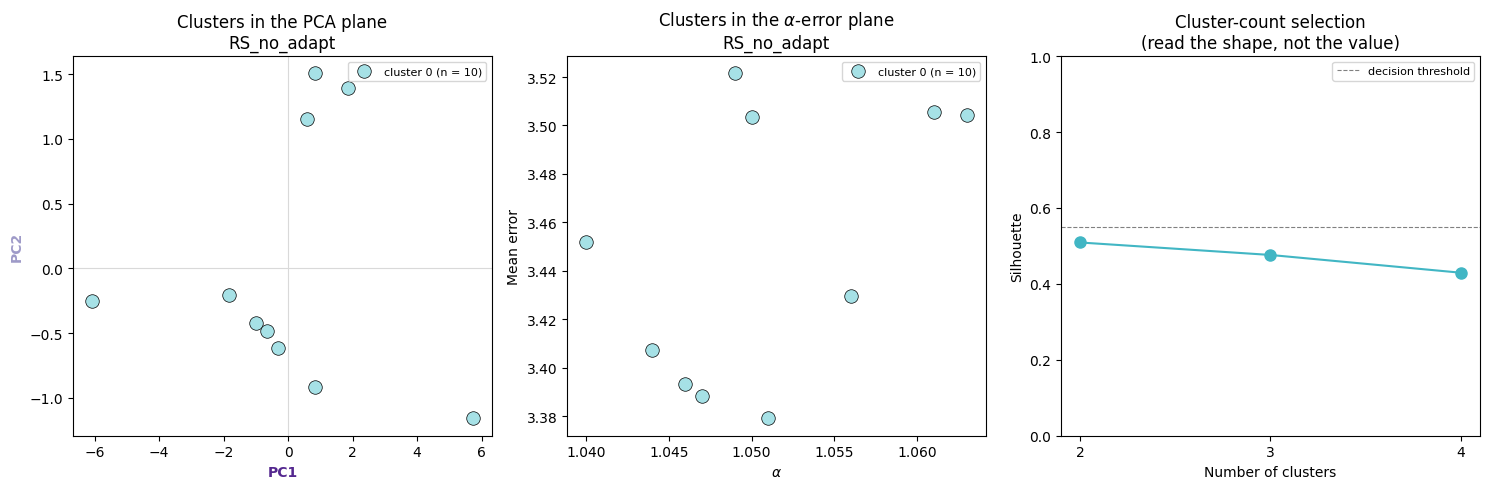

In [9]:
for m in neuron_models:
    fig = plot_clusters(m, alpha[m], err[m], labels[m], scores[m], cluster_diag[m])
    figs.append(fig)

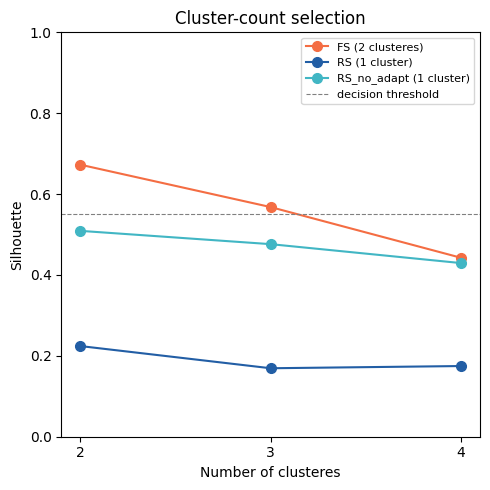

In [10]:
fig, ax = plt.subplots(figsize=(5, 5))
for m in neuron_models:
    plt.plot(cluster_diag[m]['n_clusters'], cluster_diag[m]['silhouette'],
             'o-', color=color_palette[m], ms=7,
             label=f"{m} ({len(np.unique(labels[m]))} cluster"
                   f"{'es' if len(np.unique(labels[m])) > 1 else ''})")
plt.axhline(0.55, ls='--', color='gray', lw=0.8, label='decision threshold')
plt.xticks([2, 3, 4]); plt.ylim(0, 1)
plt.xlabel('Number of clusteres'); plt.ylabel('Silhouette')
plt.title('Cluster-count selection'); plt.legend(fontsize=8)
plt.tight_layout()
figs.append(fig)

In [11]:
for m in neuron_models:
    k = len(np.unique(labels[m]))
    print(f'=== {m} : {k} cluster(es) ===')
    if k > 1:
        s, cmns = cluster_summary(labels[m], alpha[m], err[m], poly[m], params_name)
        print(s.to_string(index=False))
        flips = cmns[cmns.sign_flip != ''].params_name.tolist()
        print(f'  coefficients changing sign between clusteres: {flips}')
    print()

=== FS : 2 cluster(es) ===
 cluster  n  alpha_min  alpha_max  error_mean  error_std  r_alpha_error_within  p_alpha_error_within
       0  6      1.113      1.138    7.554189   0.075973             -0.195389              0.710646
       1  4      1.156      1.191    6.849001   0.514952              0.131938              0.868062
  coefficients changing sign between clusteres: ['P_mu', 'P_sig', 'P_sig2', 'P_tau2', 'P_mu_sig', 'P_sig_tau']

=== RS : 1 cluster(es) ===

=== RS_no_adapt : 1 cluster(es) ===



---
## 6. Dimensionality

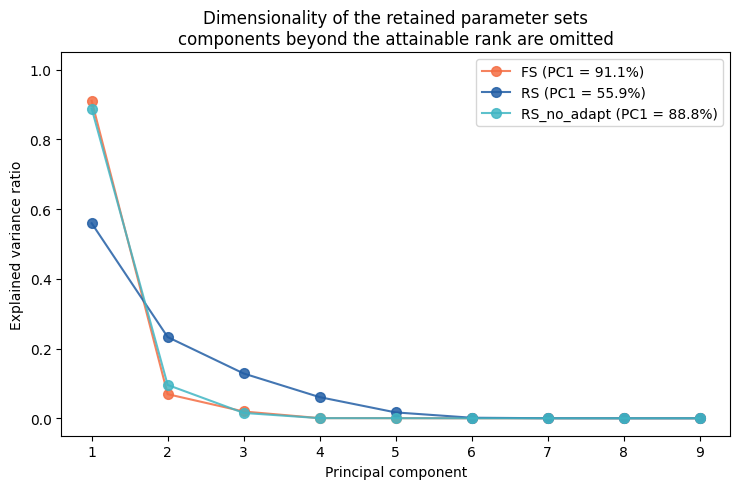

In [12]:
fig = plt.figure(figsize=(7.5, 5))

for m in neuron_models:
    rank_max = min(poly[m].shape[0] - 1, n_params)
    plt.plot(range(1, rank_max + 1), expl[m][:rank_max], 'o-',
             color=color_palette[m], label=f'{m} (PC1 = {100 * expl[m][0]:.1f}%)',
             ms=7, alpha=0.85)

plt.xlabel('Principal component')
plt.ylabel('Explained variance ratio')
plt.title('Dimensionality of the retained parameter sets\n'
          'components beyond the attainable rank are omitted')
plt.xticks(range(1, n_params))
plt.ylim(-0.05, 1.05)
plt.legend()
plt.tight_layout()

figs.append(fig)

In [13]:
for m in neuron_models:
    c = np.cumsum(expl[m])
    print(f'{m:>12s}: PC1 = {100 * expl[m][0]:5.2f}%, '
          f'PC1+PC2 = {100 * c[1]:5.2f}%, PC1+PC2+PC3 = {100 * c[2]:5.2f}%')

          FS: PC1 = 91.05%, PC1+PC2 = 97.97%, PC1+PC2+PC3 = 99.91%
          RS: PC1 = 55.94%, PC1+PC2 = 79.23%, PC1+PC2+PC3 = 92.07%
 RS_no_adapt: PC1 = 88.83%, PC1+PC2 = 98.39%, PC1+PC2+PC3 = 99.93%


---
## 7. Loadings, with the signs aligned

> The sign of a principal component is not determined by the decomposition. Before
> these bars can be compared, each component is oriented to agree with the reference
> model. Without this step an identical structure can appear inverted.

In [14]:
loadings = {}
ref = align_pca_signs(pcas[REFERENCE].components_[:3])

for m in neuron_models:
    loadings[m] = align_pca_signs(pcas[m].components_[:3], reference=ref)

for m in neuron_models:
    flipped = np.sign((pcas[m].components_[:3] * loadings[m]).sum(axis=1)) < 0
    print(f'{m:>12s}: components flipped by the alignment -> '
          f'{[f"PC{i+1}" for i in range(3) if flipped[i]] or "none"}')

          FS: components flipped by the alignment -> none
          RS: components flipped by the alignment -> ['PC1']
 RS_no_adapt: components flipped by the alignment -> ['PC1', 'PC2']


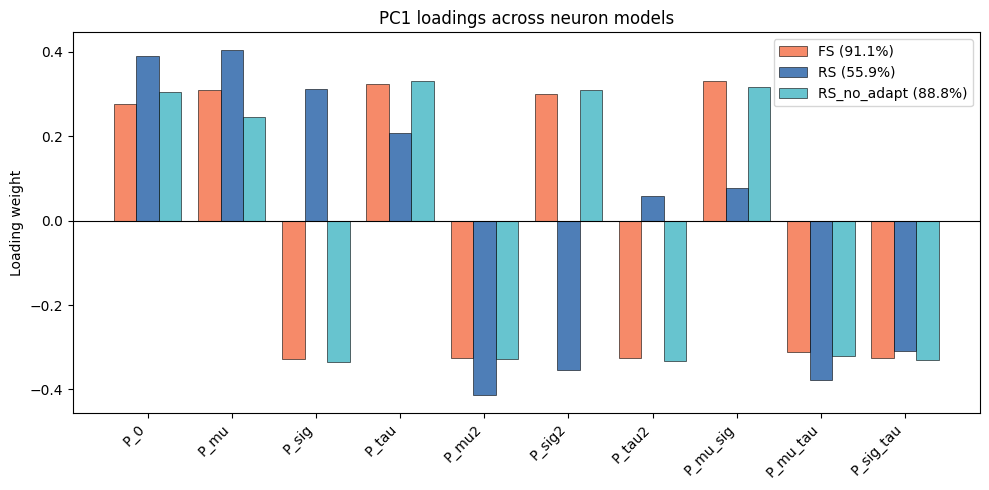

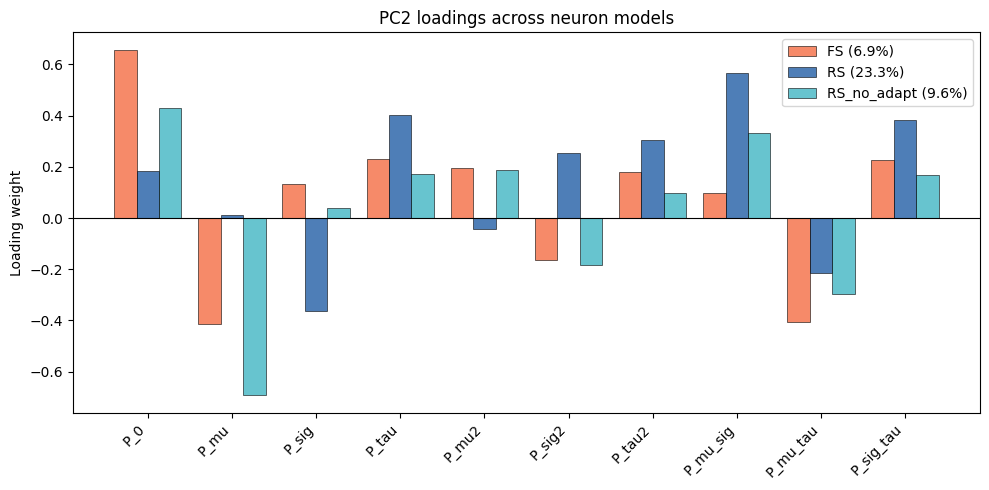

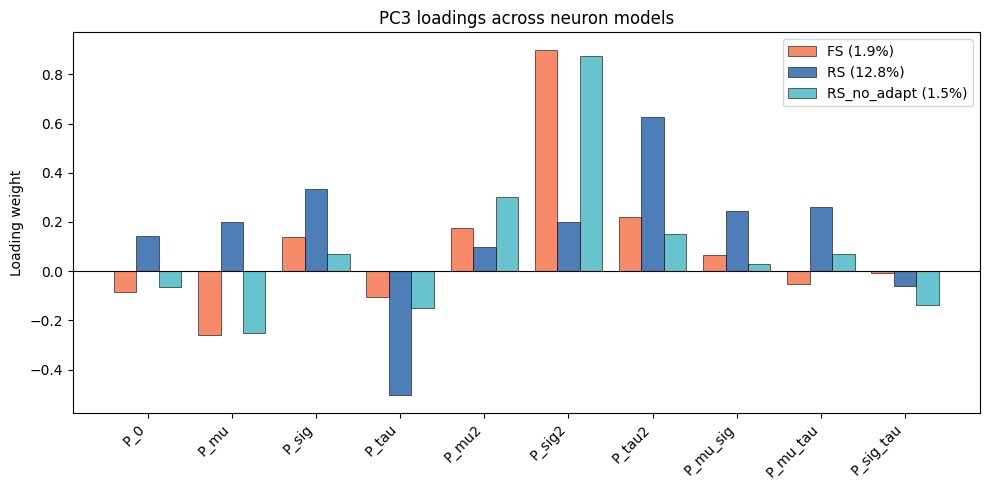

In [15]:
for pc_index in range(3):
    fig = plot_pc_loadings_comparison(loadings, params_name, pc_index=pc_index,
                                      expl_var_dict=expl)
    figs.append(fig)

In [16]:
# How similar are the dominant modes across models, once the signs are fixed?
print('Cosine similarity between PC1 directions (1.0 = identical mode):\n')
sim = pd.DataFrame(index=neuron_models, columns=neuron_models, dtype=float)
for m1 in neuron_models:
    for m2 in neuron_models:
        sim.loc[m1, m2] = float(np.dot(loadings[m1][0], loadings[m2][0]))
print(sim.to_string(float_format=lambda v: f'{v:+.3f}'))

Cosine similarity between PC1 directions (1.0 = identical mode):

                FS     RS  RS_no_adapt
FS          +1.000 +0.451       +0.997
RS          +0.451 +1.000       +0.436
RS_no_adapt +0.997 +0.436       +1.000


**This is the key number in the notebook.** A cosine similarity near 1 between two
populations means their fits are degenerate along the *same* direction in parameter
space -- the degeneracy comes from the formalism. A similarity near 0 means the
populations are unconstrained in different directions, and the structure is
population-specific.

---
## 8. A common basis

The scores above come from three separate decompositions and are not comparable across
models: each is expressed in its own basis. Here a single PCA is fitted on the pooled,
standardised ensembles, and all three are projected into it. Only in this plot do the
relative positions of the populations mean anything.

Pooled PCA explained variance: [0.5196 0.4153 0.0408]


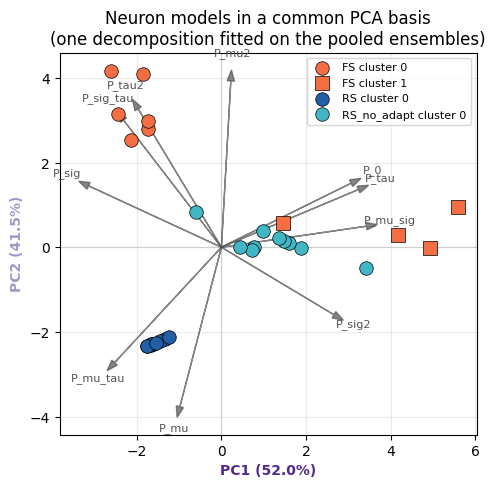

In [17]:
pooled, pooled_scores = pooled_pca(poly, n_components=3)

print('Pooled PCA explained variance:',
      np.round(pooled.explained_variance_ratio_, 4))

fig = plot_pooled_pca_scores(pooled_scores, pooled, params_name, labels_dict=labels)
figs.append(fig)

In [18]:
# Are the populations separated in the common basis, or do they overlap?
print('Centroid of each population in the common basis (PC1, PC2, PC3):\n')
for m in neuron_models:
    c = pooled_scores[m].mean(axis=0)
    r = pooled_scores[m].std(axis=0, ddof=1)
    print(f'  {m:>12s}: ' + '  '.join(f'{c[k]:+6.2f} +- {r[k]:4.2f}' for k in range(3)))

print('\nPairwise centroid distances:')
for i, m1 in enumerate(neuron_models):
    for m2 in neuron_models[i+1:]:
        d = np.linalg.norm(pooled_scores[m1].mean(0) - pooled_scores[m2].mean(0))
        print(f'  {m1} <-> {m2}: {d:.2f}')

Centroid of each population in the common basis (PC1, PC2, PC3):

            FS:  +0.36 +- 3.34   +2.15 +- 1.57   +0.49 +- 0.62
            RS:  -1.57 +- 0.17   -2.26 +- 0.07   +0.23 +- 0.02
   RS_no_adapt:  +1.20 +- 1.04   +0.11 +- 0.34   -0.72 +- 0.19

Pairwise centroid distances:
  FS <-> RS: 4.82
  FS <-> RS_no_adapt: 2.51
  RS <-> RS_no_adapt: 3.76


**RS against RS_no_adapt is the controlled comparison.** The two populations differ in
adaptation and nothing else, so any separation between them in this basis is
attributable to adaptation. FS differs in several respects at once and cannot be used
the same way.

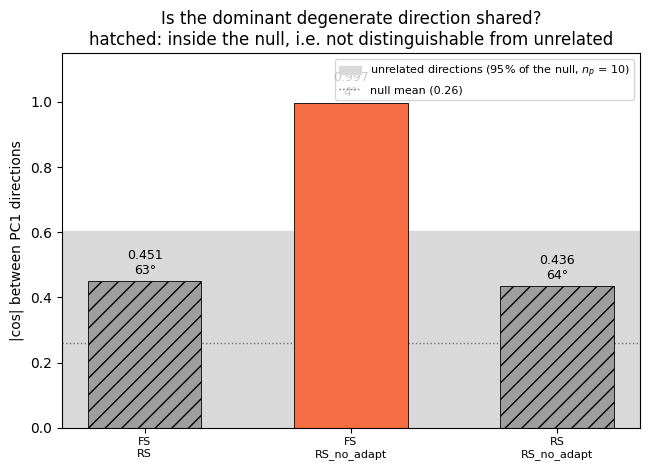

In [19]:
fig, table= plot_pc1_similarity(loadings, n_params)
figs.append(fig)

In [20]:
table

,pair,model_a,model_b,cosine,angle_deg,p_null
0,FS\nRS,FS,RS,0.450528,63.222405,1.643393e-01
1,FS\nRS_no_adapt,FS,RS_no_adapt,0.997358,4.165671,1.459943e-11
2,RS\nRS_no_adapt,RS,RS_no_adapt,0.435511,64.182185,1.806142e-01


In [21]:
save_figs(fig_path, fig_name, figs)
print(f'{len(figs)} figures written to {fig_path}/{fig_name}-figs.pdf')

11 figures written to figures/Comparing_TF_fitted_params_FS_RS_RS_no_adapt-figs.pdf
